In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as ss

In [2]:
B ,n = 1000, 30
mu, sig =100, 10
alpha=0.05
diff= np.linspace(-5, 5, 5)
power=[]
for j in diff:
    Decision= []
    for _ in range(B):
        t_stat,pval=ss.ttest_1samp(np.random.normal(mu+j,sig,n),100)
        Decision.append(pval<alpha)
    power.append(np.mean(Decision))
print(power)
df=pd.DataFrame({"Difference":diff,"Power":power})
print(df)

[np.float64(0.751), np.float64(0.28), np.float64(0.054), np.float64(0.251), np.float64(0.758)]
   Difference  Power
0        -5.0  0.751
1        -2.5  0.280
2         0.0  0.054
3         2.5  0.251
4         5.0  0.758


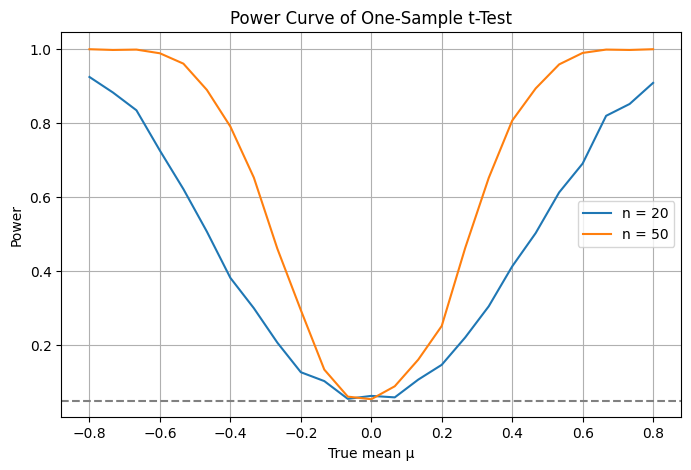

In [4]:
mu0 = 0
sigma = 1
n_small = 20
n_large = 50
mu_grid = np.linspace(-0.8, 0.8, 25)

def power_curve(n):
    power = []
    for mu in mu_grid:
        rejections = 0
        for _ in range(B):
            x = np.random.normal(mu, sigma, n)
            t_stat, p_val = ss.ttest_1samp(x, mu0)
            if p_val < alpha:
                rejections += 1
        power.append(rejections / B)
    return power

power_small = power_curve(n_small)
power_large = power_curve(n_large)

plt.figure(figsize=(8,5))
plt.plot(mu_grid, power_small, label=f"n = {n_small}")
plt.plot(mu_grid, power_large, label=f"n = {n_large}")
plt.axhline(alpha, linestyle="--", color="gray")
plt.xlabel("True mean μ")
plt.ylabel("Power")
plt.title("Power Curve of One-Sample t-Test")
plt.legend()
plt.grid()
plt.show()
